# Univariate Data Analysis for the credit scoring purposes
## Artem Matevosian

## Disclaimer: the following notebook is written in **Julia**.
Which means, you either:
* have Julia installed;
* or choose it in Google Colab;
* or do not run the code cells at all until one of the first two happens.

<div>
<img src="memes/julia.jpg" width="400"/>
</div>


## Minimal preprocessing to be able to run the baseline
Due to extremely specific patterns of data entry errors, some columns will be excluded.
See https://www.kaggle.com/datasets/yasserh/loan-default-dataset/discussion/550138 for more information

Note: I managed to obtain this information on my own, when after dropping all the missing values the target column became univalued, then went to Kaggle Discussions to see why.

In [1]:
using DataFrames
using CSV

In [2]:
df = CSV.read("data/Loan_Default.csv", DataFrame)
suspicious_columns = ["Interest_rate_spread", "rate_of_interest", "Upfront_charges", "property_value", "LTV", "dtir1"]
select!(df, Not(suspicious_columns))

# 148670×28 DataFrame
# columns: ID	year	loan_limit	Gender	approv_in_adv	loan_type	loan_purpose	Credit_Worthiness	open_credit	business_or_commercial	loan_amount	term	Neg_ammortization	interest_only	lump_sum_payment	construction_type	occupancy_type	Secured_by	total_units	income	credit_type	Credit_Score	co-applicant_credit_type	age	submission_of_application	Region	Security_Type	Status

Row,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status
,Int64,Int64,String3?,String31,String7?,String7,String3?,String3,String7,String7,Int64,Float64?,String7?,String15,String15,String3,String3,String7,String3,Float64?,String7,Int64,String3,String7?,String15,String15,String15,Int64
1,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,south,direct,1
2,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,360.0,not_neg,not_int,lpsm,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,North,direct,1
3,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,360.0,neg_amm,not_int,not_lpsm,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,south,direct,0
4,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,North,direct,0
5,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,North,direct,0
6,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10080.0,EXP,864,EXP,35-44,not_inst,North,direct,0
7,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5040.0,EXP,860,EXP,55-64,to_inst,North,direct,0
8,24897,2019,missing,Female,nopre,type1,p4,l1,nopc,nob/c,266500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,3780.0,CIB,863,CIB,55-64,to_inst,North,direct,0
9,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5580.0,CIB,580,EXP,55-64,to_inst,central,direct,0


In [3]:
show(describe(df), allrows=true, allcols=true)

28×7 DataFrame
 Row │ variable                   mean       min       median    max                nmissing  eltype                  
     │ Symbol                     Union…     Any       Union…    Any                Int64     Type                    
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ ID                         99224.5    24890     99224.5   173559                    0  Int64
   2 │ year                       2019.0     2019      2019.0    2019                      0  Int64
   3 │ loan_limit                            cf                  ncf                    3344  Union{Missing, String3}
   4 │ Gender                                Female              Sex Not Available         0  String31
   5 │ approv_in_adv                         nopre               pre                     908  Union{Missing, String7}
   6 │ loan_type                             type1               type3                   

Can we just try and drop every line with missing values? How many values are we going to have?

In [4]:
println("Fraction of data left: ", nrow(dropmissing(df)) / nrow(df))

Fraction of data left: 0.9087778300934957


I am willing to try and see if any missing values dropped are going to heavily affect target distribution.

In [5]:
df = dropmissing(df)

# 135108×28 DataFrame, columns are the same

Row,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status
,Int64,Int64,String3,String31,String7,String7,String3,String3,String7,String7,Int64,Float64,String7,String15,String15,String3,String3,String7,String3,Float64,String7,Int64,String3,String7,String15,String15,String15,Int64
1,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,south,direct,1
2,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,360.0,not_neg,not_int,lpsm,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,North,direct,1
3,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,360.0,neg_amm,not_int,not_lpsm,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,south,direct,0
4,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,North,direct,0
5,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,North,direct,0
6,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10080.0,EXP,864,EXP,35-44,not_inst,North,direct,0
7,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5040.0,EXP,860,EXP,55-64,to_inst,North,direct,0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5580.0,CIB,580,EXP,55-64,to_inst,central,direct,0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,436500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,6720.0,CIB,788,EXP,55-64,to_inst,south,direct,0


In [6]:
sum(df.Status) / length(df.Status)

0.2533306687982947

Compared to previous mean target value of 0.246445, it does not seem an extreme influence.

In [7]:
# The columns where only a single value is present - previously this code managed to drop the target column :)
singular_columns = [col for col ∈ names(df) if length(unique(df[!, col])) == 1]
select!(df, Not(singular_columns))

# only year column got dropped here

Row,ID,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status
,Int64,String3,String31,String7,String7,String3,String3,String7,String7,Int64,Float64,String7,String15,String15,String3,String3,String7,String3,Float64,String7,Int64,String3,String7,String15,String15,String15,Int64
1,24890,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,south,direct,1
2,24891,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,360.0,not_neg,not_int,lpsm,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,North,direct,1
3,24892,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,360.0,neg_amm,not_int,not_lpsm,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,south,direct,0
4,24893,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,North,direct,0
5,24894,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,North,direct,0
6,24895,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,10080.0,EXP,864,EXP,35-44,not_inst,North,direct,0
7,24896,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5040.0,EXP,860,EXP,55-64,to_inst,North,direct,0
8,24898,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,5580.0,CIB,580,EXP,55-64,to_inst,central,direct,0
9,24899,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,436500,360.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,6720.0,CIB,788,EXP,55-64,to_inst,south,direct,0


In [8]:
function one_hot_encode(df, column)
    ux = unique(df[!, column])
    DataFrames.transform(df, @. Symbol(column) => ByRow(isequal(ux)) .=> Symbol(column, :_, ux))
end

function one_hot_encode(df)
    non_numeric_columns = setdiff(names(df), names(df, Number))
    res = df
    for column in non_numeric_columns
        res = one_hot_encode(res, column)
    end
    return res
end

function prepare_df(df)
    res_df = one_hot_encode(df)
    original_categoricals = setdiff(names(df), names(df, Number))
    select!(res_df, Not(original_categoricals))
    DataFrames.transform!(res_df, names(res_df, Bool) .=> ByRow(Float64), renamecols=false)
    DataFrames.transform!(res_df, names(res_df, Int) .=> ByRow(Float64), renamecols=false)
    return res_df
end

OHEd_df = prepare_df(df)

# 135108×65 DataFrame - all categorical columns are one-hot encoded, but nothing else

Row,ID,loan_amount,term,income,Credit_Score,Status,loan_limit_cf,loan_limit_ncf,Gender_Sex Not Available,Gender_Male,Gender_Joint,Gender_Female,approv_in_adv_nopre,approv_in_adv_pre,loan_type_type1,loan_type_type2,loan_type_type3,loan_purpose_p1,loan_purpose_p4,loan_purpose_p3,loan_purpose_p2,Credit_Worthiness_l1,Credit_Worthiness_l2,open_credit_nopc,open_credit_opc,business_or_commercial_nob/c,business_or_commercial_b/c,Neg_ammortization_not_neg,Neg_ammortization_neg_amm,interest_only_not_int,interest_only_int_only,lump_sum_payment_not_lpsm,lump_sum_payment_lpsm,construction_type_sb,construction_type_mh,occupancy_type_pr,occupancy_type_sr,occupancy_type_ir,Secured_by_home,Secured_by_land,total_units_1U,total_units_2U,total_units_3U,total_units_4U,credit_type_EXP,credit_type_EQUI,credit_type_CRIF,credit_type_CIB,co-applicant_credit_type_CIB,co-applicant_credit_type_EXP,age_25-34,age_55-64,age_35-44,age_45-54,age_65-74,age_>74,age_<25,submission_of_application_to_inst,submission_of_application_not_inst,Region_south,Region_North,Region_central,Region_North-East,Security_Type_direct,Security_Type_Indriect
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,24890.0,116500.0,360.0,1740.0,758.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,24891.0,206500.0,360.0,4980.0,552.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,24892.0,406500.0,360.0,9480.0,834.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,24893.0,456500.0,360.0,11880.0,587.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
5,24894.0,696500.0,360.0,10440.0,602.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6,24895.0,706500.0,360.0,10080.0,864.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
7,24896.0,346500.0,360.0,5040.0,860.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
8,24898.0,376500.0,360.0,5580.0,580.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,24899.0,436500.0,360.0,6720.0,788.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.

## Baseline

In [9]:
using MLJ, MLJLinearModels, Random


coerce!(OHEd_df, :Status => OrderedFactor)

train, test = partition(eachindex(OHEd_df.Status), 0.8, shuffle=true, rng=52)

LogisticClassifier = @load LogisticClassifier pkg=MLJLinearModels
model = LogisticClassifier(penalty=:l2, solver=MLJLinearModels.Newton(), lambda=0.00, fit_intercept=true, penalize_intercept=false)

X = select(OHEd_df, setdiff(names(OHEd_df), ["Status", "ID"]))
y = OHEd_df.Status

mach = machine(model, X, y)
fit!(mach, rows=train, verbosity=2)

ŷ = MLJ.predict(mach, rows=test)
ŷ_prob = predict_mode(mach, rows=test)

y_true = OHEd_df[test, :Status]

f1_score = f1score(ŷ_prob, y_true)
println("F1 Score: ", f1_score)

auc = MLJ.auc(ŷ, y_true)
println("ROC-AUC: ", auc)

[ Info: For silent loading, specify `verbosity=0`. 


import MLJLinearModels ✔


[ Info: Training machine(LogisticClassifier(lambda = 0.0, …), …).
┌ Info: Solver: Newton{Optim.Options{Float64, Nothing}, @NamedTuple{}}
│   optim_options: Optim.Options{Float64, Nothing}
└   newton_options: @NamedTuple{} NamedTuple()


F1 Score: 0.3645931020110451
ROC-AUC: 0.5516982158172127


## Descriptive statistics: numeric variables

In [10]:
describe(df[!, names(df, Number)])

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,ID,99163.4,24890,99082.5,173559,0,Int64
2,loan_amount,3.29477e5,16500,296500.0,3576500,0,Int64
3,term,333.69,96.0,360.0,360.0,0,Float64
4,income,6962.77,0.0,5760.0,578580.0,0,Float64
5,Credit_Score,699.769,500,699.0,900,0,Int64
6,Status,0.253331,0,0.0,1,0,Int64


We are missing some of the statstics! This is a perfect excuse to flex Julia syntax that bears striking resemblance to my Prob&Stat notes from 2nd year:

In [11]:
Σ = sum

sum (generic function with 24 methods)

In [12]:
function hand_mean(X)
    n = length(X)
    Σ(X) / n
end

function hand_median(X)
    n = length(X)
    X = sort(X)
    if isodd(n)
        X[(n+1)÷2]
    else
        (X[n÷2] + X[n÷2+1]) / 2
    end
end

function hand_std(X)
    n = length(X)
    x̄ = hand_mean(X)
    s² = Σ((X.-x̄).^2) / (n-1)
    √s²
end

function hand_skewness(X)
    n = length(X)
    x̄ = hand_mean(X)
    s = hand_std(X)
    (Σ((X.-x̄).^3) / n) / s^3
end

function hand_kurtosis(X)
    n = length(X)
    x̄ = hand_mean(X)
    s = hand_std(X)
    (Σ((X.-x̄).^4) / n) / s^4
end

function hand_quantile(X, p)
    X = sort(X)
    n = length(X)
    idx = p * (n - 1) + 1
    if idx ≤ 1
        return X[1]
    elseif idx ≥ n
        return X[n]
    end
    i = floor(Int, idx)
    f = idx - i
    X[i] + f * (X[i+1] - X[i])
end

# я теперь extremely slay
function hand_stats(data)
    Dict(
        :x̄ => hand_mean(data),
        :ν => hand_median(data),
        :s => hand_std(data),
        :min => minimum(data),
        :max => maximum(data),
        :range => maximum(data) - minimum(data),
        :q1 => hand_quantile(data, 0.25),
        :q3 => hand_quantile(data, 0.75),
        :skewness => hand_skewness(data),
        :kurtosis => hand_kurtosis(data)
    )
end

hand_stats (generic function with 1 method)

In [13]:
using Statistics, StatsBase

function builtin_stats(data)
    Dict(
        :x̄ => mean(data),
        :ν => median(data),
        :s => std(data),
        :min => minimum(data),
        :max => maximum(data),
        :range => maximum(data) - minimum(data),
        :q1 => quantile(data, 0.25),
        :q3 => quantile(data, 0.75),
        :skewness => skewness(data),
        :kurtosis => kurtosis(data)
    )
end

builtin_stats (generic function with 1 method)

In [14]:
for col in setdiff(names(df, Number), ["ID", "Status"])
    println(col, ":")
    hand = hand_stats(df[!, col])
    builtin = builtin_stats(df[!, col])
    for (statistic, value) in hand
        println("    ", statistic, ": ", value, " (", builtin[statistic], ")")
    end
    println()
end

loan_amount:
    max: 3576500 (3576500)
    ν: 296500.0 (296500.0)
    q1: 196500.0 (196500.0)
    x̄: 329476.7297273292 (329476.7297273292)
    s: 184861.16989183368 (184861.16989183368)
    q3: 436500.0 (436500.0)
    skewness: 1.7162420054969652 (1.7162610597855814)
    range: 3560000 (3560000)
    kurtosis: 12.634762114994315 (9.634949149106145)
    min: 16500 (16500)

term:
    max: 360.0 (360.0)
    ν: 360.0 (360.0)
    q1: 360.0 (360.0)
    x̄: 333.68954466056783 (333.68954466056783)
    s: 59.827024041263854 (59.827024041263854)
    q3: 360.0 (360.0)
    skewness: -2.0786675299959407 (-2.0786906080530745)
    range: 264.0 (264.0)
    kurtosis: 5.7444672377041455 (2.74455227383843)
    min: 96.0 (96.0)

income:
    max: 578580.0 (578580.0)
    ν: 5760.0 (5760.0)
    q1: 3720.0 (3720.0)
    x̄: 6962.768451905143 (6962.768451905143)
    s: 6498.481789915667 (6498.481789915667)
    q3: 8520.0 (8520.0)
    skewness: 17.606885360229644 (17.60708083771719)
    range: 578580.0 (578580.

Note how all the stats are close to built-in ones. However, built-in kurtosis function refers to **excess** kurtosis that equals by convention to kurtosis - 3.

Interpretation of skewness and kurtosis:
1. credit score is the only symmetrical numeric predictor (skewness is close to 0), others are skewed
2. credit score is lightweight in terms of tails (lowest abs(excess kurtosis)), others are heavy-tailed, **especially** income (kurtosis of 912)

## Visualization: numeric variables

In [15]:
using StatsPlots, Plots, KernelDensity
gr()

function plot_hist_density(col_data, col_name; bins=:auto, α=0.6)
    data = collect(skipmissing(col_data))
    
    if bins == :auto
        # Freedman-Diaconis rule https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule
        IQR = quantile(data, 0.75) - quantile(data, 0.25)
        n = length(data)
        bin_width = 2IQR / (∛n)
        n_bins = max(10, ceil(Integer, (maximum(data) - minimum(data)) / bin_width))
        bins = n_bins
    end
    
    p = plot()
    
    histogram!(p, data, bins=bins, alpha=α, color=:lightblue,
               normalize=:pdf, label="Histogram", linewidth=0)
    
    kde_est = kde(data)
    plot!(p, kde_est.x, kde_est.density, lw=2, color=:red, 
          label="KDE", xlabel=col_name, ylabel="Density")
    
    # vertical lines for mean and median
    μ = mean(data)
    med = median(data)
    vline!(p, [μ], lw=2, color=:green, linestyle=:dash, label="Mean")
    vline!(p, [med], lw=2, color=:orange, linestyle=:dash, label="Median")
    IQR = quantile(data, 0.75) - quantile(data, 0.25)
    if IQR ≠ 0
        vline!(p, [med-1.5IQR, med+1.5IQR], lw=2, color=:orange, linestyle=:dash, label="Median ± 1.5×IQR")
    end
    
    title!(p, "$col_name")
    
    return p
end

function plot_numeric_columns(df)
    for col in names(df)
        if col == "term"
            bins = 45
        else
            bins = :auto
        end
        p = plot_hist_density(df[!, col], col; bins=bins)
        display(p)
    end
end

plot_numeric_columns (generic function with 1 method)

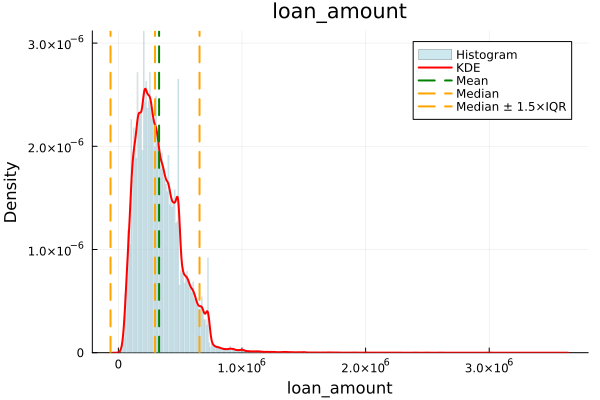

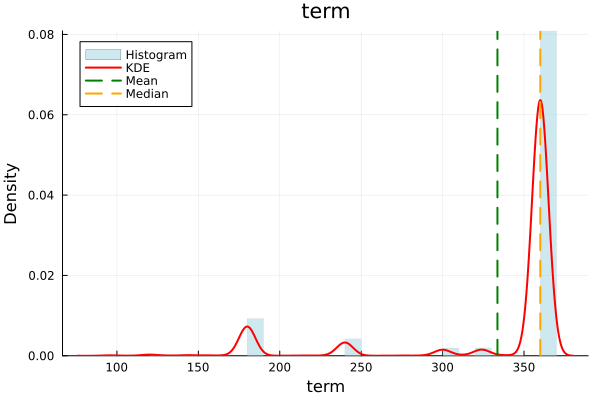

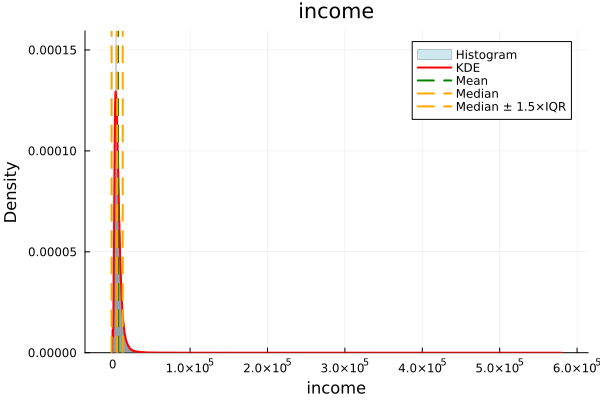

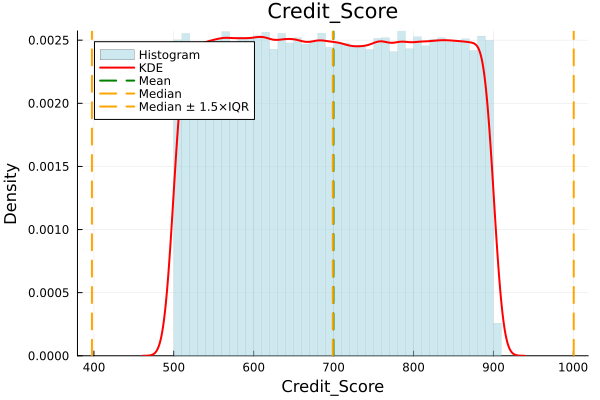

In [16]:
plot_numeric_columns(df[!, setdiff(names(df, Number), ["ID", "Status"])])

Small discussion on what we have seen:
1. Credit score resembles uniform-like distribution, so it would suffice to standardize it.
2. According to [some information one can acquire online](https://www.stat.cmu.edu/~cshalizi/ineq/21/lectures/03/lecture-03.pdf), income and wealth distributions are well modelled with LogNormal distribution except for zero-income cases and cases above 99th percentile. Given that loans are in general taken out for completely different reasons when borrower's income is top-1% of the world and "the rich are different than you and me", the lender should build another model for such cases. Not that we are going to do that - throwing out everything higher that 99th percentile should suffice for the original model.
3. It is probably impossible to make Loan Amount behave well... Unless we resort to directly projecting onto [rankits](https://en.wikipedia.org/wiki/Rankit). However, rankit projection should distort the distribution in a non-differentiable manner to force it into normality, which can (and will!) cause huge discrepancies: previously close values can end up as distant from each other as other distant values were. Anyways, taking logarithm wouldn't hurt - loan=0 is impossible case and loans are also tied to money, income and wealth. Same goes with removing one or two percentiles from above - either "rich case" or something highly specific with different motivation and model (i.e. "rich case" again).
4. Term is presumably a discrete predictor. At least we can interpret it as such and force it into [0, 1] interval that represents fraction of "year" (fraction of 360 days)

## Outliers. Transformations. Scaling. Noise removal
Following the small discussion above, let us apply some transformations and removals.
To acknowledge the fact that a person has zero income without distorting the income distribution into oblivion, we will assign them median income and introduce a special zero_income feature.
After moving zero-income cases into middle, we will be trimming both 1st and 99th percentile of income and loan amount to make the model more robust (additionally, anything like egregious data entry errors should go away)

In [17]:
function uniform_transformation(column)
    (column .- mean(column)) / std(column)
end

function income_transformation(x, ν)
    if x == 0
        log(ν), 1
    else
        log(x), 0
    end
end

function term_transformation(column)
    (column .- minimum(column)) / (maximum(column) - minimum(column))
end

function standardize(column)
    (column .- mean(column)) / std(column)
end

univariate_df = copy(df)
median_income = median(univariate_df[!, :income])
DataFrames.transform!(univariate_df, :Credit_Score => uniform_transformation, renamecols=false)
DataFrames.transform!(univariate_df, :income => ByRow(x -> income_transformation(x, median_income)) => [:income, :zero_income])
DataFrames.transform!(univariate_df, :loan_amount => (x -> log.(x)), renamecols=false)
DataFrames.transform!(univariate_df, :term => term_transformation, renamecols=false)

DataFrames.transform!(univariate_df, :income => standardize, renamecols=false)
DataFrames.transform!(univariate_df, :loan_amount => standardize, renamecols=false)

function trim_df!(df, v, pc) # removes bottom and top pc%
    vars_pc_lower_value = percentile(df[!, v], pc)
    vars_pc_upper_value = percentile(df[!, v], 100-pc)
    filter!(v => x -> vars_pc_lower_value < x < vars_pc_upper_value, df)
end

trim_df!(univariate_df, :income, 1)
trim_df!(univariate_df, :loan_amount, 1)

# 129520×28 DataFrame - some rows are dropped due to percentile trims, several columns are transformed

Row,ID,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,term,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Security_Type,Status,zero_income
,Int64,String3,String31,String7,String7,String3,String3,String7,String7,Float64,Float64,String7,String15,String15,String3,String3,String7,String3,Float64,String7,Float64,String3,String7,String15,String15,String15,Int64,Int64
1,24890,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,-1.52905,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,-1.88961,EXP,0.502616,CIB,25-34,to_inst,south,direct,1,0
2,24891,cf,Male,nopre,type2,p1,l1,nopc,b/c,-0.539318,1.0,not_neg,not_int,lpsm,sb,pr,home,1U,-0.216648,EQUI,-1.27546,EXP,55-64,to_inst,North,direct,1,0
3,24892,cf,Male,pre,type1,p1,l1,nopc,nob/c,0.631754,1.0,neg_amm,not_int,not_lpsm,sb,pr,home,1U,0.807539,EXP,1.1586,CIB,35-44,to_inst,south,direct,0,0
4,24893,cf,Male,nopre,type1,p4,l1,nopc,nob/c,0.832334,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,1.16657,EXP,-0.973356,CIB,45-54,not_inst,North,direct,0,0
5,24894,cf,Joint,pre,type1,p1,l1,nopc,nob/c,1.56283,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,0.961003,CRIF,-0.843885,EXP,25-34,not_inst,North,direct,0,0
6,24895,cf,Joint,pre,type1,p1,l1,nopc,nob/c,1.58748,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,0.905174,EXP,1.41755,EXP,35-44,not_inst,North,direct,0,0
7,24896,cf,Joint,pre,type1,p3,l1,nopc,nob/c,0.355619,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,-0.197595,EXP,1.38302,EXP,55-64,to_inst,North,direct,0,0
8,24898,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,0.499193,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,-0.0356626,CIB,-1.03378,EXP,55-64,to_inst,central,direct,0,0
9,24899,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,0.754871,1.0,not_neg,not_int,not_lpsm,sb,pr,home,1U,0.260096,CIB,0.761559,EXP,55-64,to_inst,south,direct,0,0


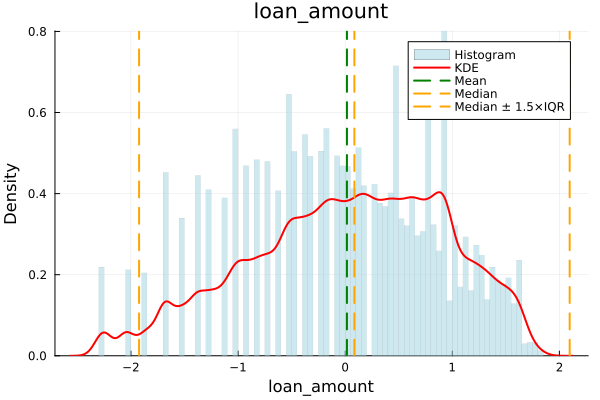

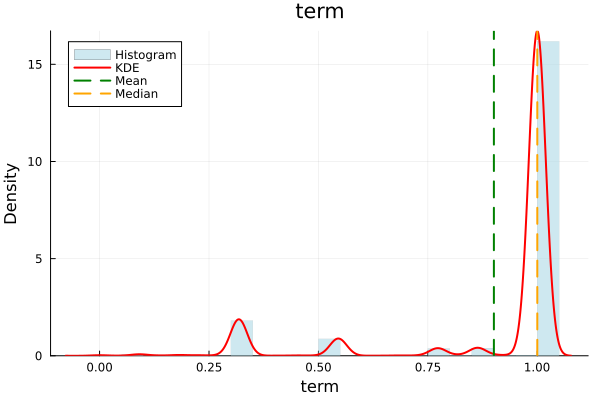

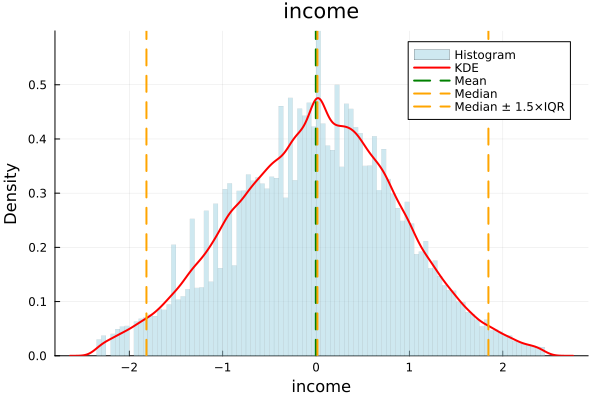

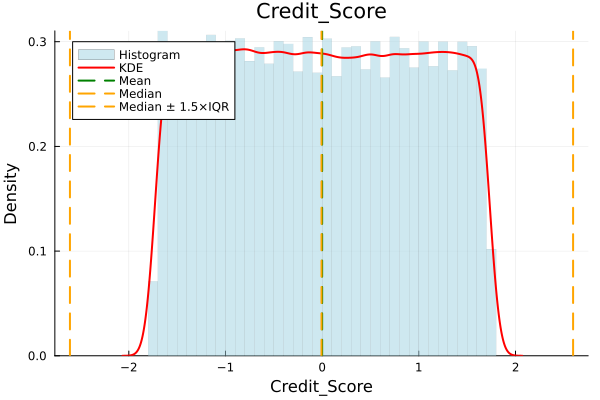

In [18]:
plot_numeric_columns(univariate_df[!, setdiff(names(df, Number), ["ID", "Status"])])

## Updated baseline

In [19]:
using MLJ, MLJLinearModels, Random

OHEd_df = prepare_df(univariate_df)
coerce!(OHEd_df, :Status => OrderedFactor)

train, test = partition(eachindex(OHEd_df.Status), 0.8, shuffle=true, rng=52)

LogisticClassifier = @load LogisticClassifier pkg=MLJLinearModels
model = LogisticClassifier(penalty=:none, solver=MLJLinearModels.LBFGS(), lambda=0.00, fit_intercept=true, penalize_intercept=false)

X = select(OHEd_df, setdiff(names(OHEd_df), ["Status", "ID"]))
y = OHEd_df.Status

mach = machine(model, X, y)
fit!(mach, rows=train, verbosity=2)

ŷ = MLJ.predict(mach, rows=test)
ŷ_prob = predict_mode(mach, rows=test)

y_true = OHEd_df[test, :Status]

f1_score = f1score(ŷ_prob, y_true)
println("F1 Score: ", f1_score)

auc = MLJ.auc(ŷ, y_true)
println("ROC-AUC: ", auc)

[ Info: For silent loading, specify `verbosity=0`. 


import MLJLinearModels ✔


[ Info: Training machine(LogisticClassifier(lambda = 0.0, …), …).
┌ Info: Solver: LBFGS{Optim.Options{Float64, Nothing}, @NamedTuple{}}
│   optim_options: Optim.Options{Float64, Nothing}
└   lbfgs_options: @NamedTuple{} NamedTuple()


F1 Score: 0.641347562251517
ROC-AUC: 0.8379724224060149


## Discussion

Baseline results are listed below for convenience:
* F1 Score: 0.3645931020110451
* ROC-AUC: 0.5516982158172127
* F1 Score (L2 penalty 0.01): 0.5989637305699482
* ROC-AUC (L2 penalty 0.01): 0.8219512074652104

After univariate analysis:
* F1 Score: 0.641347562251517
* ROC-AUC: 0.8379724224060149


One can indeed see an increase in classification quality even when comparing to L2-regular baseline, not to mention unregularized one.

However, this is not even the only benefit - unregularized Logistic Regression is tolerant to different scales, **but only while the optimizer/solver is tolerant to these as well.** Having said this, we can see an extra bonus here: multiple solvers (LBFGS, Newton under no regularization, **ProxGrad**, etc.) turned out to be sensitive to ill-behaved data in my experiments. After grooming data, unlocking first two solvers means unlocking extra performance, both in terms of metrics and execution time. Unlocking Proximal Gradient optimizer enables non-differentiable optimization, which was not the original point but worth mentioning.